# **Business Case: Netflix – Data Exploration and Visualization**

# **STAGE 1 — DATA EXPLORATION**

# 1. Business Understanding

Netflix wants to understand:

Which type of content should they produce?

Which countries should they focus on?

Which genres are most popular?

What is the best time to release content?

Which markets have the highest growth potential?

Goal: Converting raw Netflix data into business insights to support content acquisition and expansion strategies.

# 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)



# 3. Load Dataset

In [3]:
!pip install gdown

In [4]:
import gdown
netflix = "1piPkFMfP1Oj5JbR9HIHic8kt6hmzGDUs"
gdown.download(
    f"https://drive.google.com/uc?id={netflix}",
    "netflix.csv",
    quiet=False
)
df = pd.read_csv("netflix.csv")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1piPkFMfP1Oj5JbR9HIHic8kt6hmzGDUs
To: /content/netflix.csv
100%|██████████| 3.40M/3.40M [00:00<00:00, 25.6MB/s]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 4. Basic Information:
> Is the dataset complete and suitable for analysis?



In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.tail()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4788,s4789,Movie,Katt Williams: Kattpacalypse,Marcus Raboy,Katt Williams,United States,"July 3, 2018",2012,TV-MA,61 min,Stand-Up Comedy,Urban comic Katt Williams ushers in Kattpacaly...
6053,s6054,Movie,A Princess for Christmas,Michael Damian,"Katie McGrath, Sir Roger Moore, Sam Heughan, T...",United States,"August 28, 2020",2011,TV-PG,91 min,"Children & Family Movies, Dramas, Romantic Movies","At the invitation of a relative, young Jules D..."
4183,s4184,TV Show,The World's Most Extraordinary Homes,NaN,"Piers Taylor, Caroline Quentin",United Kingdom,"January 18, 2019",2019,TV-G,3 Seasons,"British TV Shows, Docuseries, International TV...",Award-winning architect Piers Taylor and actre...
5758,s5759,Movie,Russell Peters: Almost Famous,Dave Higby,Russell Peters,United States,"October 7, 2016",2016,TV-MA,73 min,Stand-Up Comedy,The comic comes home to Toronto to sound off o...
5533,s5534,Movie,Sandy Wexler,Steven Brill,"Adam Sandler, Jennifer Hudson, Kevin James, Te...",United States,"April 14, 2017",2017,TV-14,131 min,Comedies,When a hapless but dedicated talent manager si...


In [8]:
df.shape

(8807, 12)

# **`Observation`**

> Dataset contains 8807 rows and 12 columns.


# 5. Data Types



In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# **Observation**

> Most categorical columns are stored as object datatype.

# 6. Duplicate Check



In [10]:

df.duplicated().sum()


np.int64(0)


# **Observation**

> No duplicate records found.

# 7. Missing Values



In [11]:

df.isnull().sum()

(
df.isnull()
.sum()
.sort_values(ascending=False)
)



,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


# **Observation**

> Director, Cast and Country contain the highest number of missing values.

Business implication

> Missing director and cast information may affect actor/director trend analysis.

# 8. Summary Statistics



In [12]:
# Numerical

df.describe()




,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [13]:
# Categorical

df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# 9. Unique Values

In [14]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [15]:
for col in df.columns:
    print(col)
    print(df[col].nunique())


show_id
8807
type
2
title
8807
director
4528
cast
7692
country
748
date_added
1767
release_year
74
rating
17
duration
220
listed_in
514
description
8775


# **Business implication**

> Netflix offers multiple ratings and genres to serve diverse audience groups.

# 10. Dataset Memory

In [16]:
df.memory_usage(deep=True)

,0
Index,132
show_id,474471
type,480930
title,599158
director,495687
cast,1631213
country,517757
date_added,561028
release_year,70456
rating,470514



# Business implication

> Converting categorical variables reduces memory usage.

# **STAGE 2 — DATA-CLEANING**

In [17]:
## Business Question

# Can we improve the quality of the data before analysis?


### Missing Values

df['director']=df['director'].fillna("Unknown")

df['cast']=df['cast'].fillna("Unknown")

df['country']=df['country'].fillna("Unknown")

# Drop

df.dropna(subset=['date_added'],inplace=True)



# Observation

Critical missing records removed

In [18]:
# Convert Date

df['date_added']=pd.to_datetime(df['date_added'],format="mixed")


# Extract

df['added_year']=df['date_added'].dt.year

df['added_month']=df['date_added'].dt.month

df['added_month_name']=df['date_added'].dt.month_name()

df['added_day']=df['date_added'].dt.day

df['added_weekday']=df['date_added'].dt.day_name()

In [19]:
df.head(15)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_month_name,added_day,added_weekday
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,25,Saturday
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,24,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,24,Friday
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,24,Friday
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,24,Friday
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9,September,24,Friday
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,September,24,Friday
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,September,24,Friday
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021,9,September,24,Friday
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9,September,24,Friday


In [20]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


# Business value

Now Netflix can analyze

Best year
Best month
Best weekday

In [21]:
# Split Multi-value Columns


# Country

country_df=df.copy()
country_df['country']=country_df['country'].str.split(',')
country_df=country_df.explode('country')
country_df['country']=country_df['country'].str.strip()
country_df=country_df.reset_index(drop=True)


# Cast

cast_df = df.copy()
# Split multiple actors
cast_df['cast'] = cast_df['cast'].str.split(',')
# Convert each actor into a separate row
cast_df = cast_df.explode('cast')
# Remove extra spaces
cast_df['cast'] = cast_df['cast'].str.strip()
# Reset index
cast_df = cast_df.reset_index(drop=True)




#Listed_in

genre_df = df.copy()
# Split multiple genres
genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
# Convert each genre into a separate row
genre_df = genre_df.explode('listed_in')
# Remove extra spaces
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
# Reset index
genre_df = genre_df.reset_index(drop=True)

In [22]:
country_df.head(10)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_month_name,added_day,added_weekday
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,25,Saturday
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,24,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,24,Friday
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,24,Friday
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,24,Friday
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9,September,24,Friday
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,September,24,Friday
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,September,24,Friday
8,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,September,24,Friday
9,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Burkina Faso,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,September,24,Friday


In [23]:
cast_df[ 'cast'].head(10)

,cast
0,Unknown
1,Ama Qamata
2,Khosi Ngema
3,Gail Mabalane
4,Thabang Molaba
5,Dillon Windvogel
6,Natasha Thahane
7,Arno Greeff
8,Xolile Tshabalala
9,Getmore Sithole


In [24]:
genre_df['listed_in'].head(10)

,listed_in
0,Documentaries
1,International TV Shows
2,TV Dramas
3,TV Mysteries
4,Crime TV Shows
5,International TV Shows
6,TV Action & Adventure
7,Docuseries
8,Reality TV
9,International TV Shows


In [25]:
print(df.shape)
print(country_df.shape)

(8797, 17)
(10840, 17)


# Each country becomes one observation.

In [26]:
# Movie Duration


movies=df[df['type']=="Movie"].copy()
movies=movies.dropna(subset=['duration'])
movies['duration']=movies['duration'].str.replace(" min","")
movies['duration']=movies['duration'].astype(int)

In [27]:
df['duration'].head(10)

,duration
0,90 min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
5,1 Season
6,91 min
7,125 min
8,9 Seasons
9,104 min


# Conclusion:
The movie duration column is successfully cleaned and converted into a numerical format, making it suitable for statistical analysis and visualization.

# **STAGE 3 —VISUALIZATION**

# Step 1: Top 10 Countries Code

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

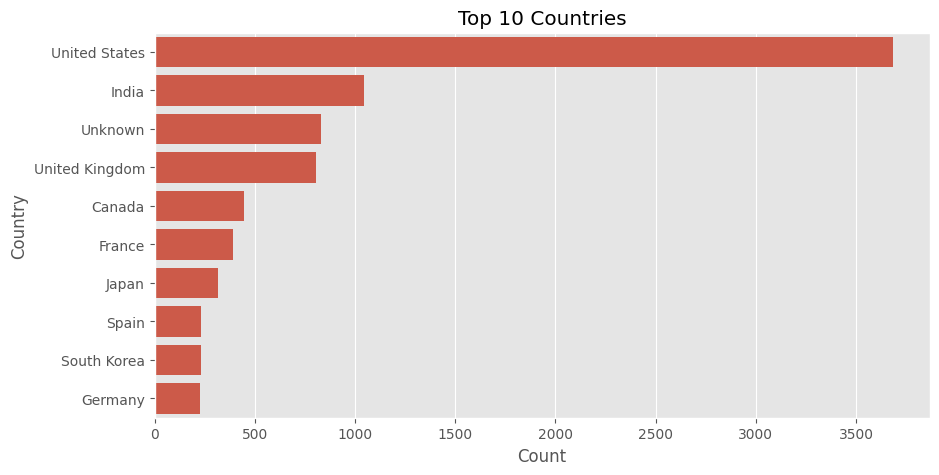

In [31]:
country_df = (
    df.assign(country=df['country'].fillna('Unknown').str.split(', '))
      .explode('country')
      .reset_index(drop=True)
)

plt.figure(figsize=(10,5))

sns.countplot(
    data=country_df,
    y='country',
    order=country_df['country'].value_counts().head(10).index
)

plt.title("Top 10 Countries")
plt.xlabel("Count")
plt.ylabel("Country")

plt.show()

# Observation

The United States has the highest number of Netflix titles, followed by India and the United Kingdom.

# Step 2: Top 10 Genres Code

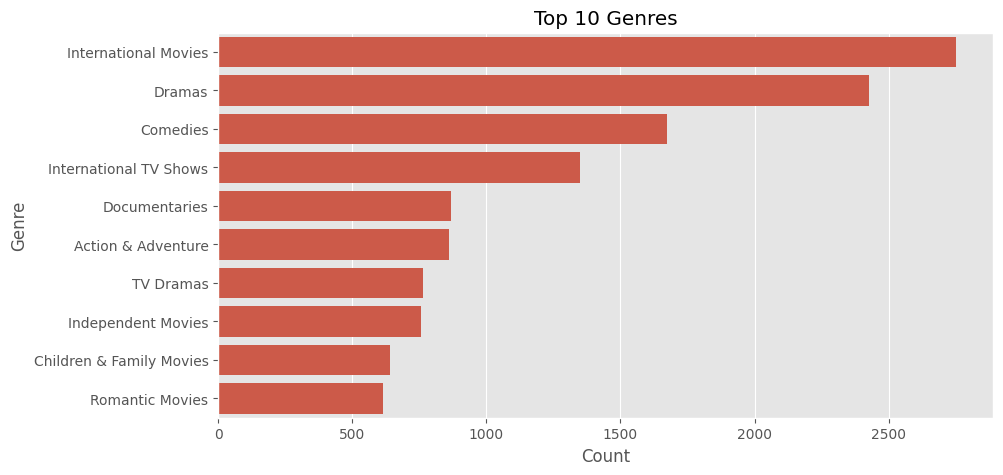

In [32]:
genre_df = ( df.assign(listed_in=df['listed_in'].str.split(', '))
               .explode('listed_in')
               .reset_index(drop=True) )

plt.figure(figsize=(10,5))

sns.countplot(
    data=genre_df,
    y='listed_in',
    order=genre_df['listed_in'].value_counts().head(10).index
    )

plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

# Observation

International Movies is the most common genre available on Netflix.

# Step 3: Movies vs TV Shows Code bold text

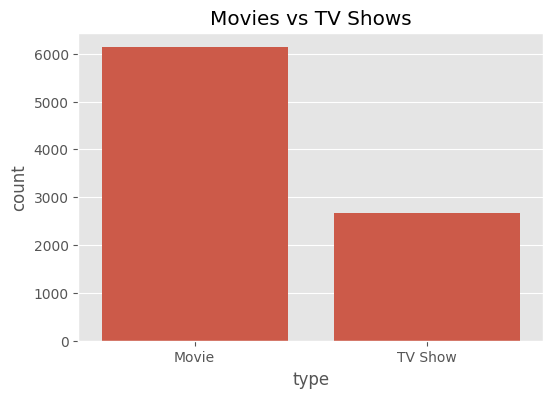

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows")

plt.show()

# Observation

Netflix offers significantly more Movies than TV Shows.

# Step 4: Content Added Per Year Code

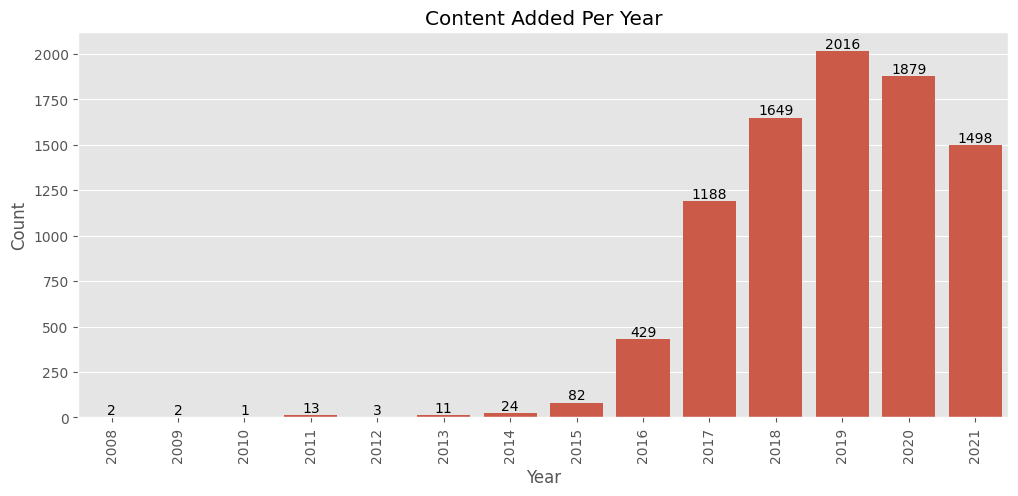

In [35]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x='added_year',
    order=sorted(df['added_year'].dropna().unique())
    )

ax.bar_label(ax.containers[0])

plt.xticks(rotation=90)

plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

# Observation

Netflix added 2,016 titles in 2019, the highest among all years.

# Step 5: Movie Duration Distribution Cleaning

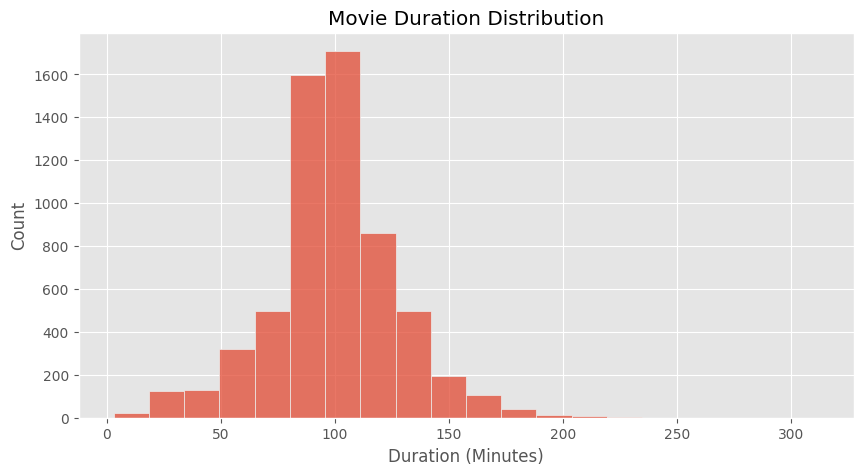

In [37]:
movies = df[df['type'] == 'Movie'].copy()

movies = movies.dropna(subset=['duration'])

movies['duration'] = (
    movies['duration'].str.replace(' min', '', regex=False).astype(int)
)

plt.figure(figsize=(10,5))

sns.histplot( data=movies, x='duration', bins=20 )

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Count")

plt.show()

# Observation

Most movies have a duration between 80 and 120 minutes.

## Step 6: Boxplot (Detect Outliers) Code

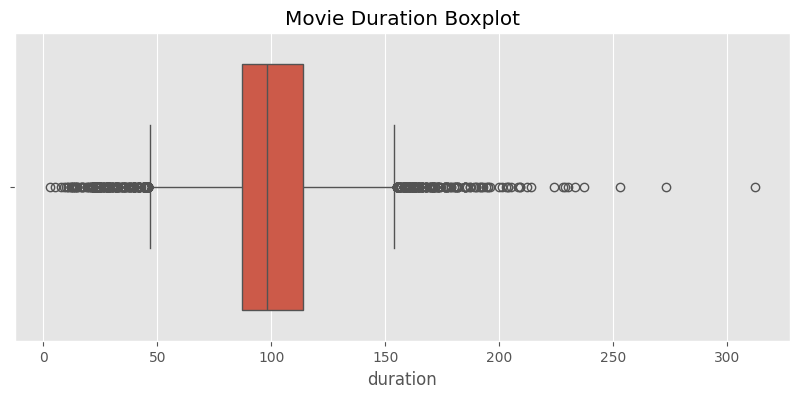

In [38]:
plt.figure(figsize=(10,4))

sns.boxplot(x=movies['duration'])

plt.title("Movie Duration Boxplot")

plt.show()

# Observation

Most movies are around 100 minutes long, while a few movies longer than 150 minutes appear as outliers.

# Step 7: Ratings Distribution Code

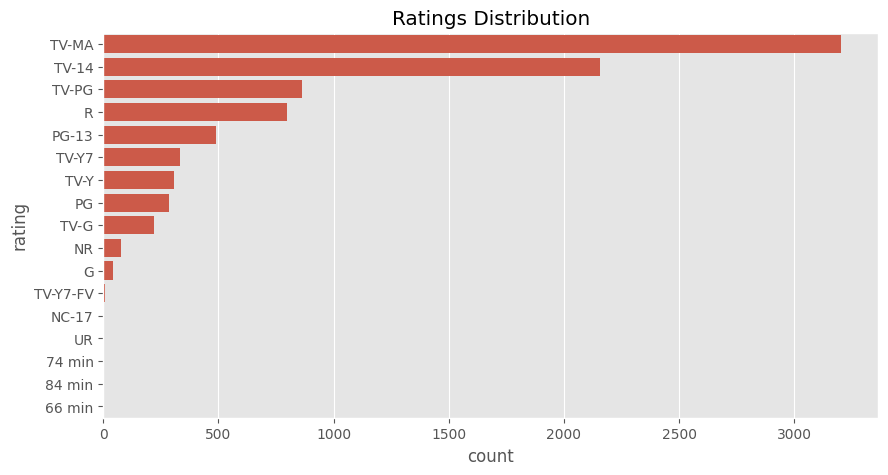

In [39]:
plt.figure(figsize=(10,5))

sns.countplot( data=df, y='rating', order=df['rating'].value_counts().index )

plt.title("Ratings Distribution")

plt.show()

# Observation

TV-MA is the most common content rating on Netflix.

# Step 8: Movies vs TV Shows (Percentage) Code

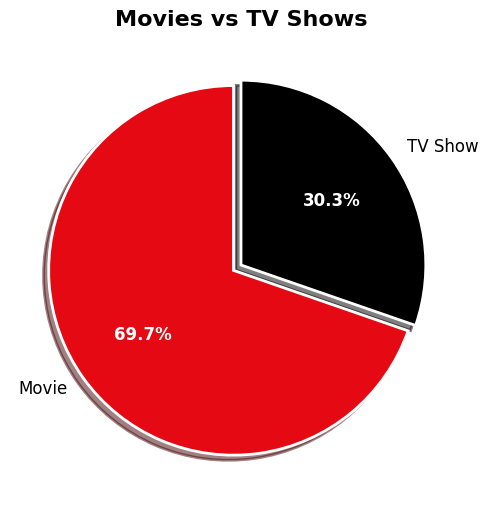

In [43]:
fig, ax = plt.subplots(figsize=(6,6))

wedges, texts, autotexts = ax.pie(
    df['type'].value_counts(),
    labels=df['type'].value_counts().index,
    autopct='%1.1f%%',
    colors=['#E50914', '#000000'],
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

# Percentage text color
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Labels color
for text in texts:
    text.set_fontsize(12)

plt.title("Movies vs TV Shows", fontsize=16, fontweight='bold')

plt.show()

# Observation

Movies account for the majority of Netflix's content library.

# **# Final Business Insights**


# Business Insight

The United States remains Netflix's largest content supplier, making it the company's most strategic production market.

---



Netflix's investment in international content indicates strong demand for localized entertainment across global markets.

---

# Final Recommendations



✅ Increase investment in India and Southeast Asia.

✅ Expand International Movie production.

✅ Maintain 80–120 minute movie duration.

✅ Release flagship content during historically high-engagement periods.

---
# Conclusion


> This analysis demonstrates that Netflix's content strategy is primarily movie-driven, with the United States and India serving as key production markets. International Movies emerged as the most popular genre, while 2019 recorded the highest content additions. These findings suggest opportunities to strengthen regional content investment, optimize release timing, and continue expanding globally through localized productions.
